# Week 1 - Exploratory Data Analysis
## ML Trading Strategy Research Project

This notebook contains the exploratory data analysis for the ML trading strategy research project. The data was extracted from 7 assets: SPY, QQQ, AAPL, MSFT, NVDA, BTC-USD, ETH-USD. The data covers daily data of 10 years from 2016-2026. The goal is to understand the statistics and patterns of the data before any models are created. Using that information, plots are created including price behavior, return distributions, tail risk, and autocorrelation structure.

## Data Collection
Firstly, the raw data has to be collected. To do this I used yfinance to pull 10 years worth of daily data from the assets. Then I saved them as DataFrames in parquet files.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("src")
from load import show_ticker_list, read_ticker
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

tickers = show_ticker_list()
df = read_ticker("AAPL")
display(df.head())

Ticker           AAPL                                             ticker
Price            Open       High        Low      Close     Volume       
2016-06-03  22.261860  22.371131  22.184459  22.291454  114019600   AAPL
2016-06-06  22.307387  23.195221  22.207223  22.453083   93170000   AAPL
2016-06-07  22.594223  22.735366  22.528204  22.544140   89638000   AAPL
2016-06-08  22.541867  22.664799  22.464467  22.523657   83392400   AAPL
2016-06-09  22.423490  22.762688  22.414384  22.685287  106405600   AAPL

## Price Series

The price series shows the raw closing price of each asset over the full 10-year period. This gives a first impression of each asset's growth trajectory, trend behavior, and any major drawdown events. Equities and crypto are expected to behave very differently in terms of volatility and magnitude of growth.

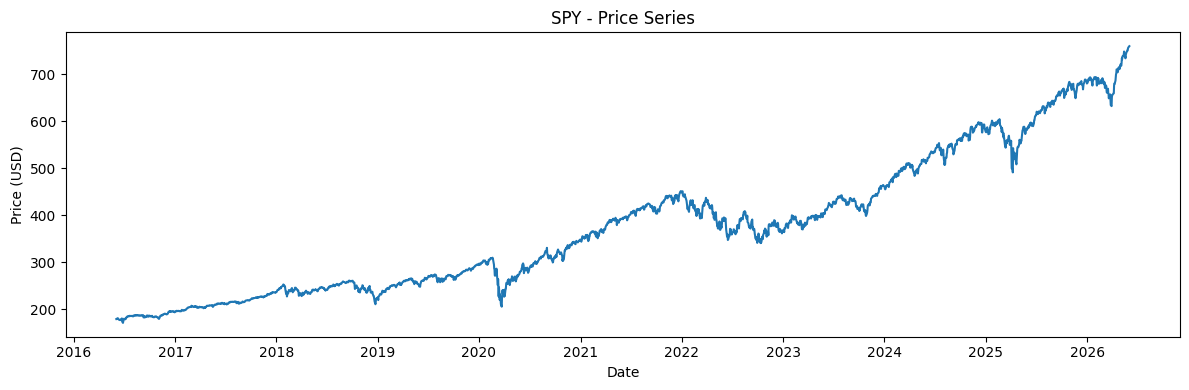

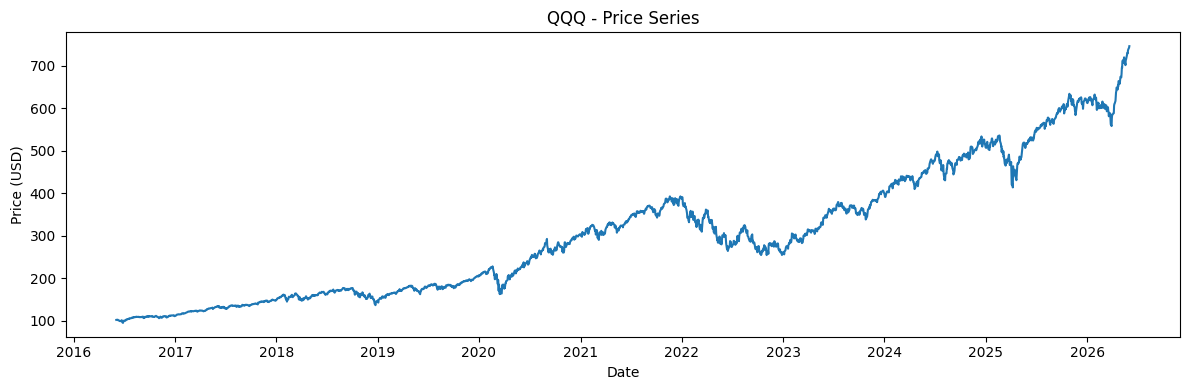

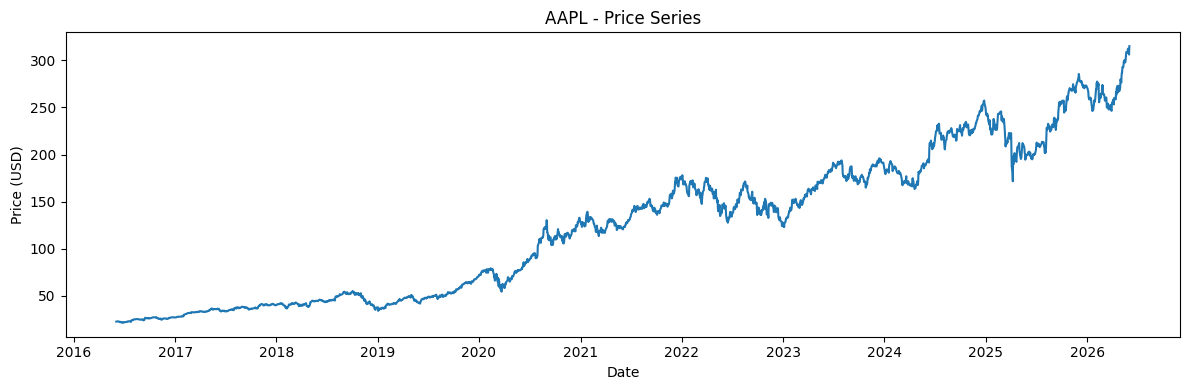

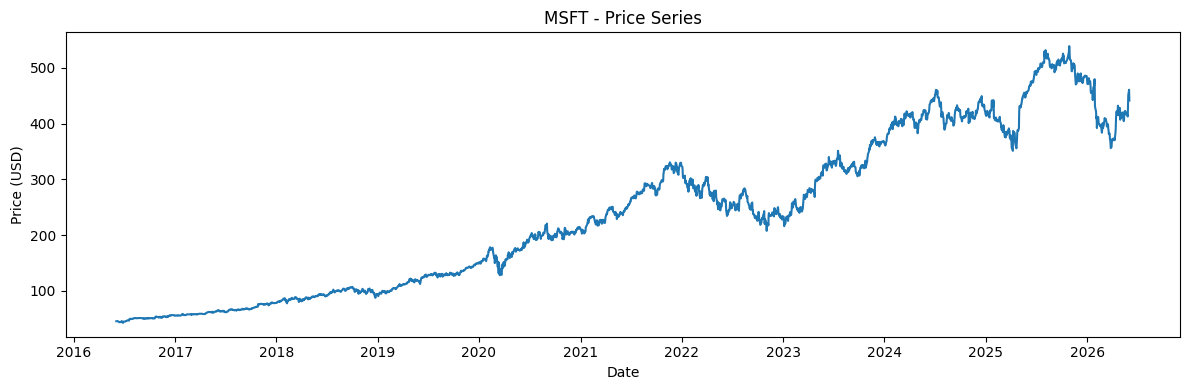

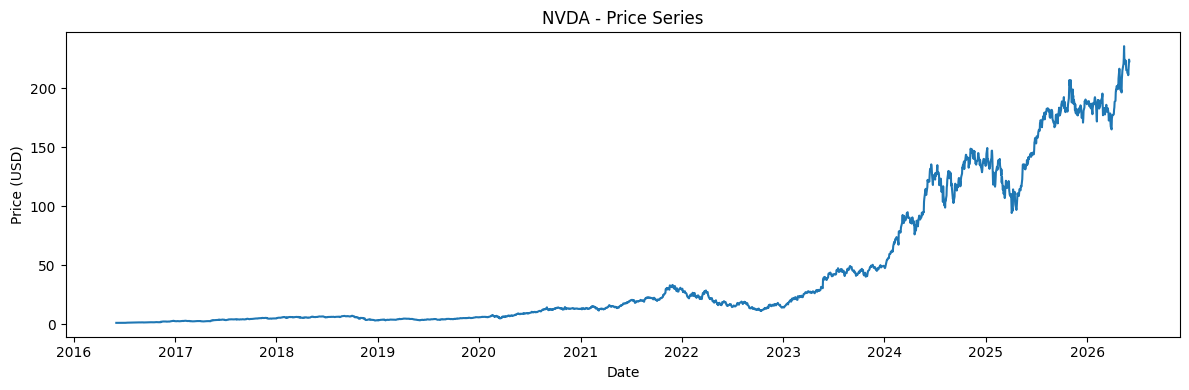

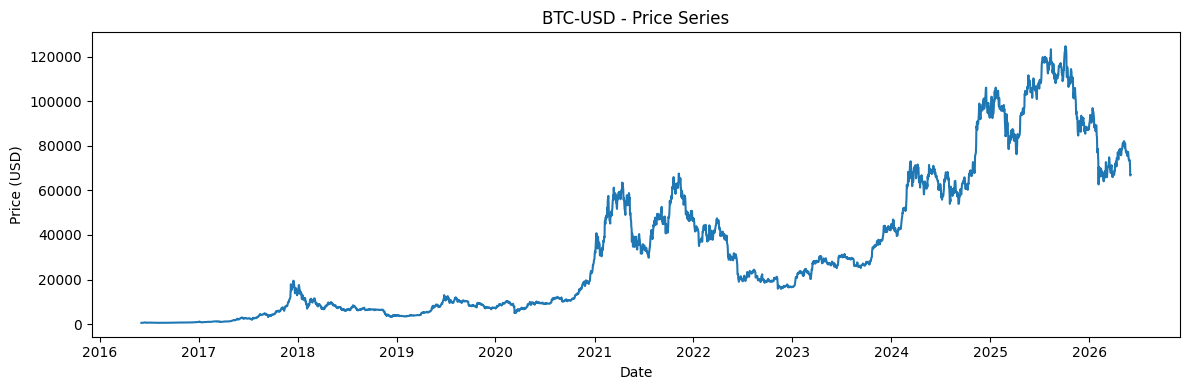

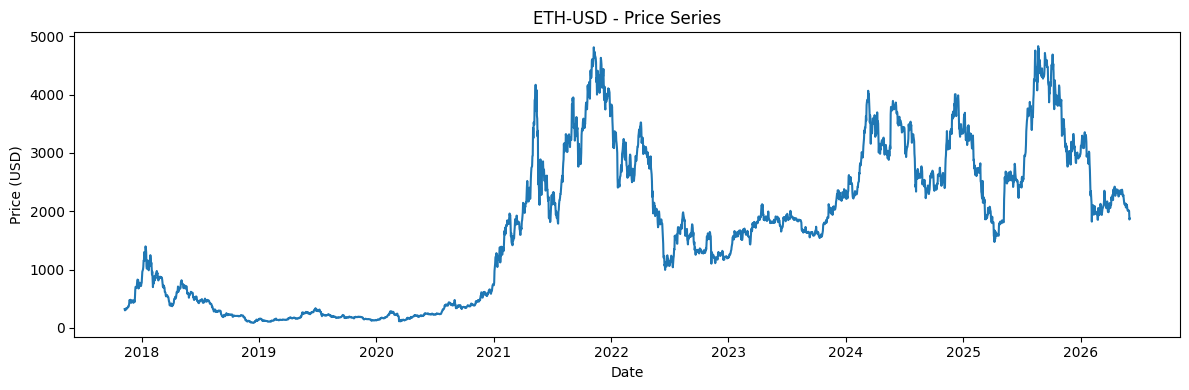

In [3]:
for ticker in tickers:
    df = read_ticker(ticker)
    close = df[ticker]["Close"]

    plt.figure(figsize=(12, 4))
    plt.plot(close)
    plt.title(f"{ticker} - Price Series")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.tight_layout()
    plt.show()

The equity assets (SPY, QQQ, AAPL, MSFT, NVDA) all show a clear upward trend over the 10-year period, with NVDA showing the most dramatic growth driven by the AI boom. The crypto assets (BTC-USD, ETH-USD) show extreme volatility with multiple boom and bust cycles. All assets experienced a notable drawdown in 2020 (COVID crash) followed by a sharp recovery.

## Return Distributions

Rather than looking at price levels, we analyze daily log returns — the percentage change in price from one day to the next. Plotting the distribution of these returns tells us how the asset behaves statistically. We overlay a normal distribution curve to see where real returns deviate from theoretical expectations. A Q-Q plot is included to precisely identify where the tails diverge from normality.

In [ ]:
for ticker in tickers:
    df = pd.read_parquet(f"data/processed/{ticker}.parquet")

    daily_log_returns = df["Log Return"].dropna()
    log_mean = np.mean(daily_log_returns)
    log_std = np.std(daily_log_returns)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    log_x = np.linspace(min(daily_log_returns), max(daily_log_returns), 200)
    log_y = norm.pdf(log_x, log_mean, log_std)

    axes[0].hist(daily_log_returns, bins=50, density=True, color='Blue', edgecolor='black')
    axes[0].plot(log_x, log_y, color="red")
    axes[0].set_title("Log Returns")
    axes[0].set_xlabel("Returns")
    axes[0].set_ylabel("Density")

    probplot(daily_log_returns, dist="norm", plot=axes[1])
    axes[1].set_title("Q-Q Plot")
    axes[1].set_xlabel("Theoretical Quantiles")
    axes[1].set_ylabel("Sample Quantiles")

    plt.tight_layout()
    plt.suptitle(ticker)
   
    plt.show()

All assets show fat-tailed distributions — the actual return bars are taller and narrower in the center than the normal curve predicts, and the tails extend further. The Q-Q plots confirm this: points in both the upper right and lower left bend away from the diagonal line, forming an S-curve. This is particularly pronounced for BTC-USD and ETH-USD. The implication is that extreme events — both crashes and spikes — occur far more frequently than a normal distribution would predict. Any model or risk calculation assuming normality will systematically underestimate tail risk.

## Autocorrelation

Autocorrelation measures how much a series is correlated with its own past values. We plot two versions — autocorrelation of raw returns, and autocorrelation of squared returns (a proxy for volatility). The first tests whether past returns predict future returns. The second tests whether past volatility predicts future volatility. The blue shaded bands represent the 95% confidence interval — bars outside these bands are statistically significant.

In [ ]:
for ticker in tickers:
    df = pd.read_parquet(f"data/processed/{ticker}.parquet")

    daily_log_returns = df["Log Return"].dropna()
    squared_returns = daily_log_returns ** 2

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    plot_acf(daily_log_returns, lags=40, ax=axes[0])
    axes[0].set_title("ACF - Log Returns")

    plot_acf(squared_returns, lags=40, ax=axes[1])
    axes[1].set_title("ACF - Squared Log Returns")

    plt.suptitle(ticker)
    plt.tight_layout()
    plt.show()

The autocorrelation of raw returns is essentially zero across all lags and all assets — past returns carry almost no predictive signal about future returns. This is consistent with the efficient market hypothesis and confirms that predicting direction is genuinely difficult.

The autocorrelation of squared returns tells a completely different story. Strong, persistent positive autocorrelation is visible across all assets, decaying slowly over 20+ lags. This is volatility clustering — large moves tend to follow large moves, and calm periods tend to stay calm. This pattern is well-documented in financial literature and is directly exploitable: volatility-based features like rolling standard deviation should carry meaningful signal in any model built on this data.

## Key Findings

- **Fat tails across all assets:** Return distributions are taller and narrower at the center than normal, with significantly fatter tails. Extreme events occur far more often than normality assumes — especially for BTC and ETH.
- **Returns are unpredictable in direction:** Autocorrelation of raw returns is near zero at all lags, consistent with the efficient market hypothesis. There is no simple linear pattern to exploit.
- **Volatility is predictable:** Squared returns show strong, persistent autocorrelation. High volatility days cluster together. This makes volatility-based features — rolling std, ATR, regime indicators — among the most promising inputs for any downstream model.
- **Crypto is structurally different from equities:** BTC and ETH show more extreme fat tails, higher volatility, and more dramatic boom/bust cycles than the equity assets. Models trained on equities may not generalize to crypto without adaptation.
- **Normal distribution assumptions are invalid:** Any risk model or strategy metric that assumes normally distributed returns will underestimate tail risk across this entire asset universe.